In [2]:
import numpy as np
import pandas as pd
a = np.random.randn(100)  # 随机生产100个数据
print(np.var(a))          # 打印数据方差


1.0843099678667634


In [3]:
# import numpy as np
b=np.random.randn(100)*0.1
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
print(np.var(b))

0.010245226568954536


低方差过滤法（特征选择法之一）
对于特征的选择，可以直接基于方差来判断，这是最简单的。低方差的特征意味着该特征的所有样本值几乎相同，对预测影响极小，可以将其去掉。

In [6]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
# 构造特征向量
a = np.random.randn(100)  # 随机生产100个数据
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
x=np.vstack((a,b)).T
print(np.var(a))
# print(a)
print(np.var(b))
# print(b)
# print(x)  # 打印特征向量
print(x.shape)  # 打印特征向量的形状
vt=VarianceThreshold(threshold=0.01)  # 设置方差阈值为0.01
x_filterd=vt.fit_transform(x)  # 进行特征选择
# print(x_filterd)  # 打印选择后的特征向量
print(x_filterd.shape)  # 打印选择后的特征向量的形状

0.8356986665563031
0.006592383151871034
(100, 2)
(100, 1)


相关系数法（特征选择法之二）
通过计算特征与目标变量或特征之间的相关性，筛选出高相关性特征（与目标相关）或剔除冗余特征（特征间高度相关）。

[](./ml_img/皮尔逊.png)

In [5]:
# 皮尔逊相关系数用于衡量两个变量的线性相关性，取值范围[−1,1]。
import pandas as pd
advertising = pd.read_csv('./data/advertising.csv')  # 读取数据
# print(advertising.head())  # 打印数据的前5行
# print(advertising.shape)
# 数据预处理
#第一个参数是删除行第一个元素，第二个参数对每行做操作，第三个参数原地操作
advertising.drop(advertising.columns[0], axis=1, inplace=True)
# print(advertising.head())  # 打印数据的前5行
# 去掉空值
advertising.dropna(inplace=True)
# 取出特征和标签
X = advertising.drop('Sales', axis=1)  # 特征
y = advertising['Sales']  # 标签
# print(X.head())  # 打印特征的前5行
# print(y.head())  # 打印标签的前5行
# 计算特征与标签之间的相关系数
print(X.corrwith(y,method='pearson'))  # 打印特征与标签之间的相关系数

TV           0.782224
Radio        0.576223
Newspaper    0.228299
dtype: float64


In [ ]:
# 计算相关系数矩阵并画出热力图
corr_matrix = advertising.corr(method='pearson')  # 计算相关系数矩阵
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # 画出热力图
plt.title('advertising matrix')
plt.show()  # 显示图像

斯皮尔曼相关系数（第二种相关系数）


![](./ml_img/斯皮尔曼.png)

In [12]:
# 斯皮尔曼相关系数的应用
import pandas as pd
x = [55,65,70,75,85,50,60,72,80,58]
y = [[5],[8],[10],[12],[15],[3],[7],[9],[14],[6]]
Y = pd.DataFrame(y)
# print(y)
# print(Y)
X = pd.Series(x)
# print(x)
# print(X)
print(Y.corrwith(X,method='spearman'))  # 打印斯皮尔曼相关系数

0    0.987879
dtype: float64


主成分分析（PCA）
是一种常用的降维技术，通过线性变换将高维数据投影到低维空间，同时保留数据的主要变化模式。

使用sklearn.decomposition.PCA进行主成分分析。参数n_components若为小数则表示保留多少比例的信息，为整数则表示保留多少个维度。

(1000, 2)


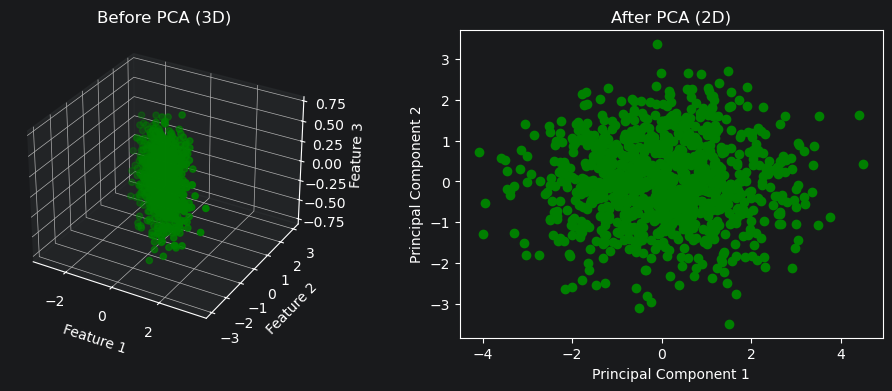

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
num_number = 1000 #每组特征生产数量
col1 = np.random.normal(loc=0, scale=1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据
col2 = np.random.normal(loc=0, scale=0.2, size=num_number)  # 生产1000个均值为0，标准差为0.1的随机数据
noise = np.random.normal(loc=0, scale=0.1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据,作为噪声
X = np.vstack([col1+col2,col2-col1,col2+noise]).T  # 将三列特征组合成一个特征矩阵
# 标准化
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)
print(X_pca.shape)  # 打印降维后的特征矩阵的形状
# 可视化
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121, projection="3d")
#print(X.shape)# 打印原始特征矩阵的形状
ax1.scatter(X[:, 0], X[:, 1], X[:,2], c="g")
ax1.set_title("Before PCA (3D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_zlabel("Feature 3")
# 转换后的2维数据可视化
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c="g")
ax2.set_title("After PCA (2D)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
plt.show()

损失函数用来判断预测结果和真实结果的偏差
损失函数本质是模型参数的函数

![](./ml_img/损失函数1.png)
![](./ml_img/损失函数2.png)